# Interaktive Analyse & Metriken-Explorer

Dieses Notebook importiert die modularisierten Analyse- und Vergleichswerkzeuge aus dem `utils_notebook`-Ordner und führt sie nacheinander aus.

## Phase 0

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
import os

# Pfad anpassen, um utils_notebook importieren zu können
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

# Nur noch die benötigten Imports aus dem L&R-Modul
from utils_notebook.LR_utils_notebook.compare_LR import (
    compare_wunden_interactive, 
    compare_categories_interactive,
    calculate_summary_LR,
    display_summary_LR,
    calculate_experts_summary_LR,
    compare_wunden_trace_interactive,
    compare_categories_trace_interactive,
    calculate_consensus_summary_LR
)
from utils_notebook.plot_compare import plot_gt_comparison

In [2]:
compare_wunden_interactive(normalised=False)

In [3]:
compare_categories_interactive(normalised=False)

## Phase 2

In [4]:
compare_wunden_interactive(normalised=True)


In [5]:
compare_categories_interactive(normalised=True)


### Roh vs. Normalisiert: Experte 1


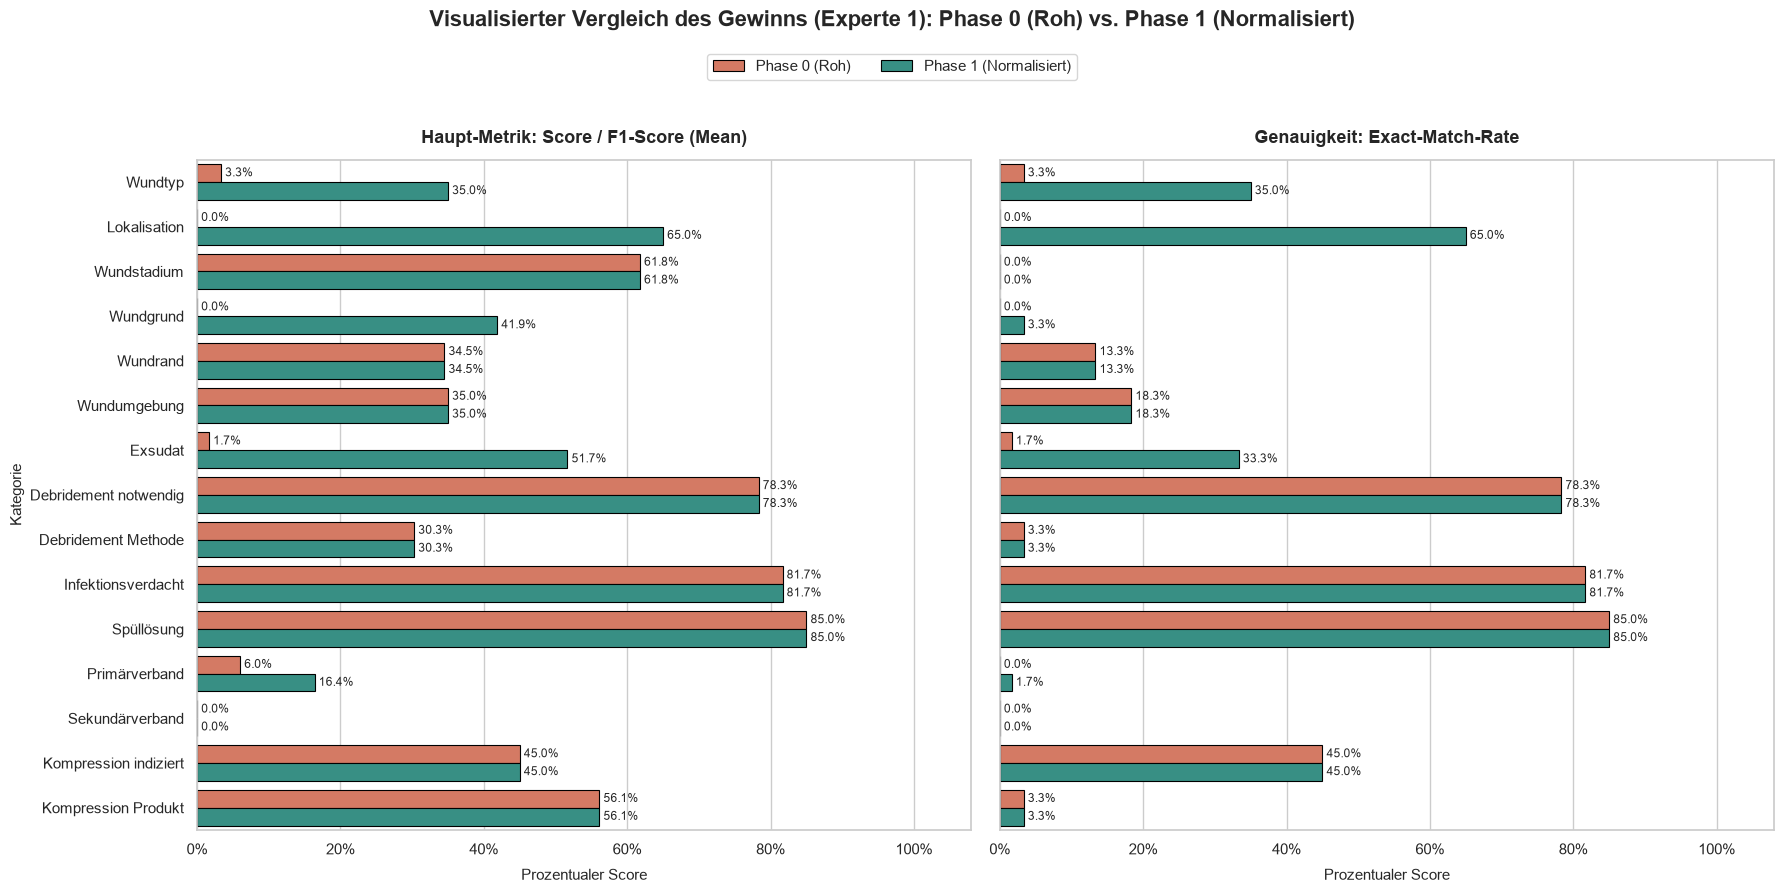

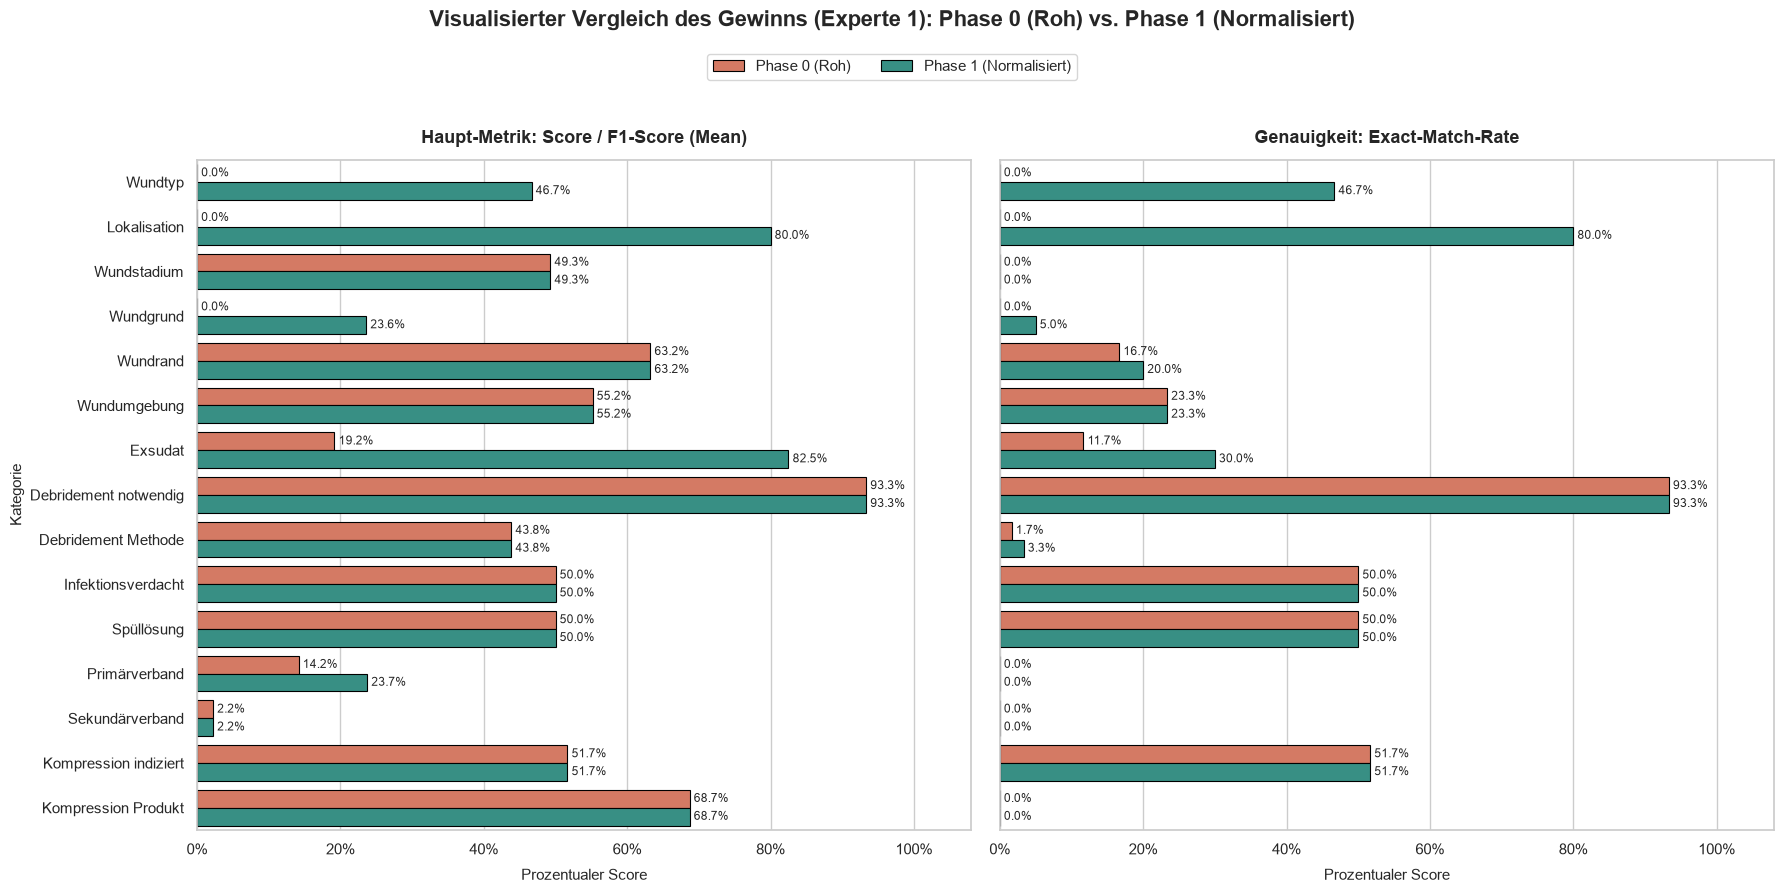

In [19]:
df_summary_raw_exp1 = calculate_summary_LR(expert_id=1, normalised=False)
df_summary_norm_exp1 = calculate_summary_LR(expert_id=1, normalised=True)
plot_gt_comparison(df_summary_raw_exp1, df_summary_norm_exp1)
# Experte 2
df_summary_raw_exp2 = calculate_summary_LR(expert_id=2, normalised=False)
df_summary_norm_exp2 = calculate_summary_LR(expert_id=2, normalised=True)
plot_gt_comparison(df_summary_raw_exp2, df_summary_norm_exp2)


In [8]:
compare_wunden_trace_interactive()


In [9]:
compare_categories_trace_interactive()


Diagramm für die Übereinstimmung zwischen Experte 1 und 2 wird generiert...


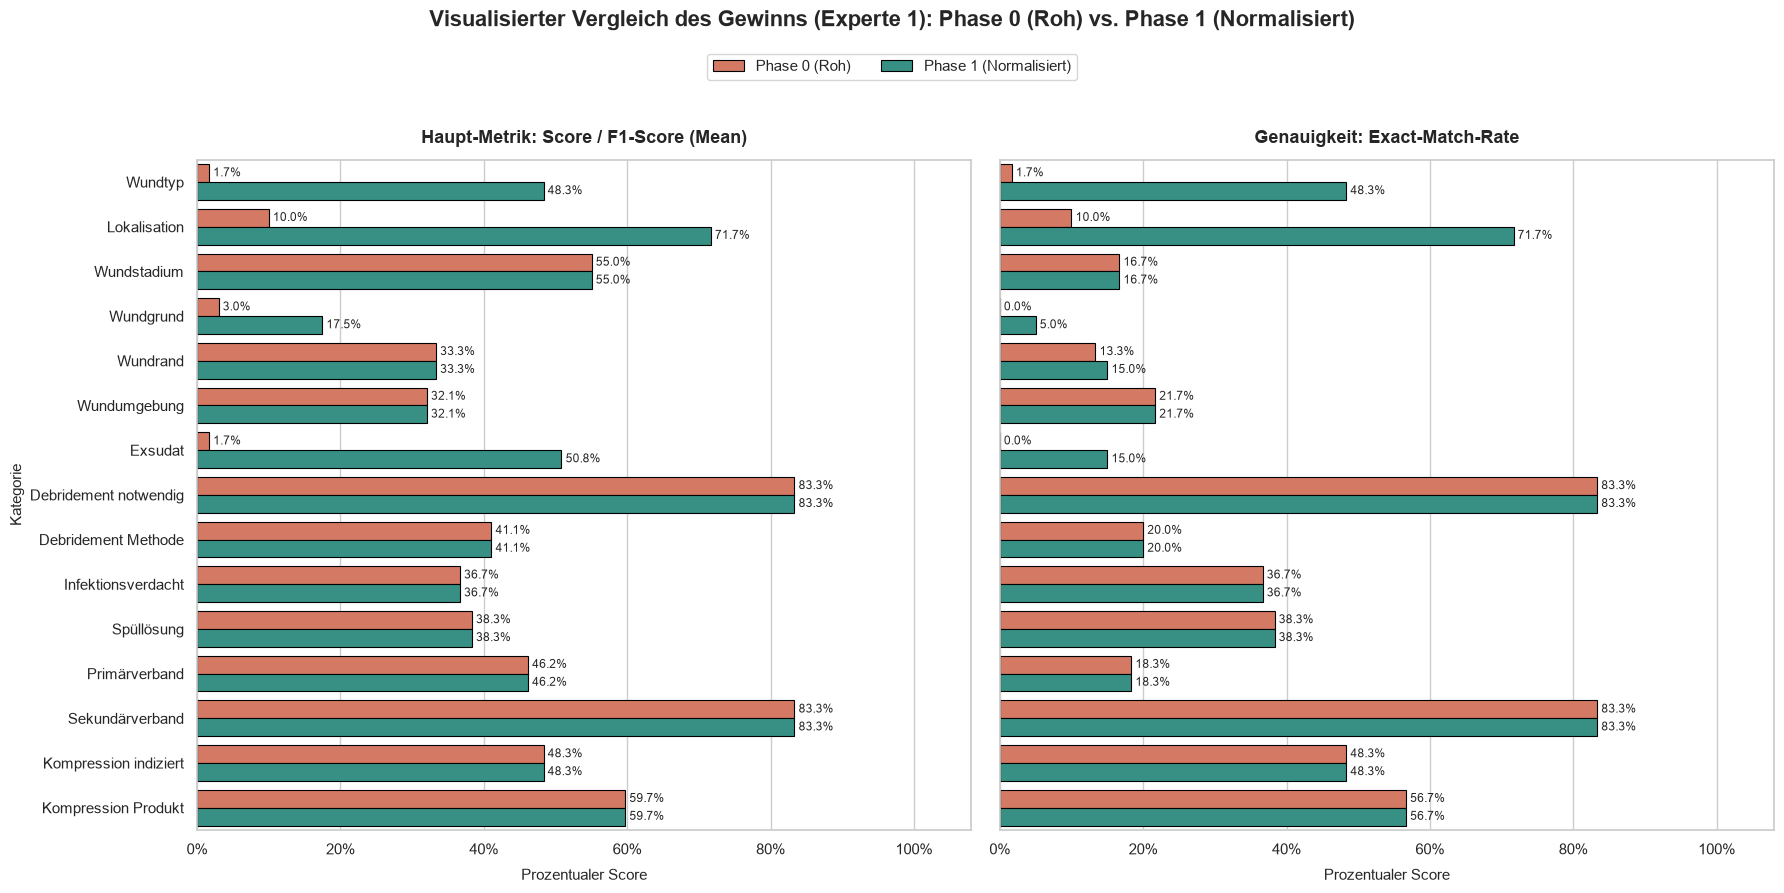

In [10]:
# =====================================================================
# ÜBEREINSTIMMUNG ZWISCHEN EXPERTE 1 UND EXPERTE 2 (ROH VS. NORMALISIERT)
# =====================================================================

# 1. Berechne die Übereinstimmung für beide Phasen (Roh vs. Normalisiert)
df_exp_raw = calculate_experts_summary_LR(normalised=False)
df_exp_norm = calculate_experts_summary_LR(normalised=True)

# 2. Zeichne das Vergleichsdiagramm
print("Diagramm für die Übereinstimmung zwischen Experte 1 und 2 wird generiert...")
plot_gt_comparison(df_exp_raw, df_exp_norm)

Diagramm für den Konsens-Score (Best-of-Both-Experts) wird generiert...


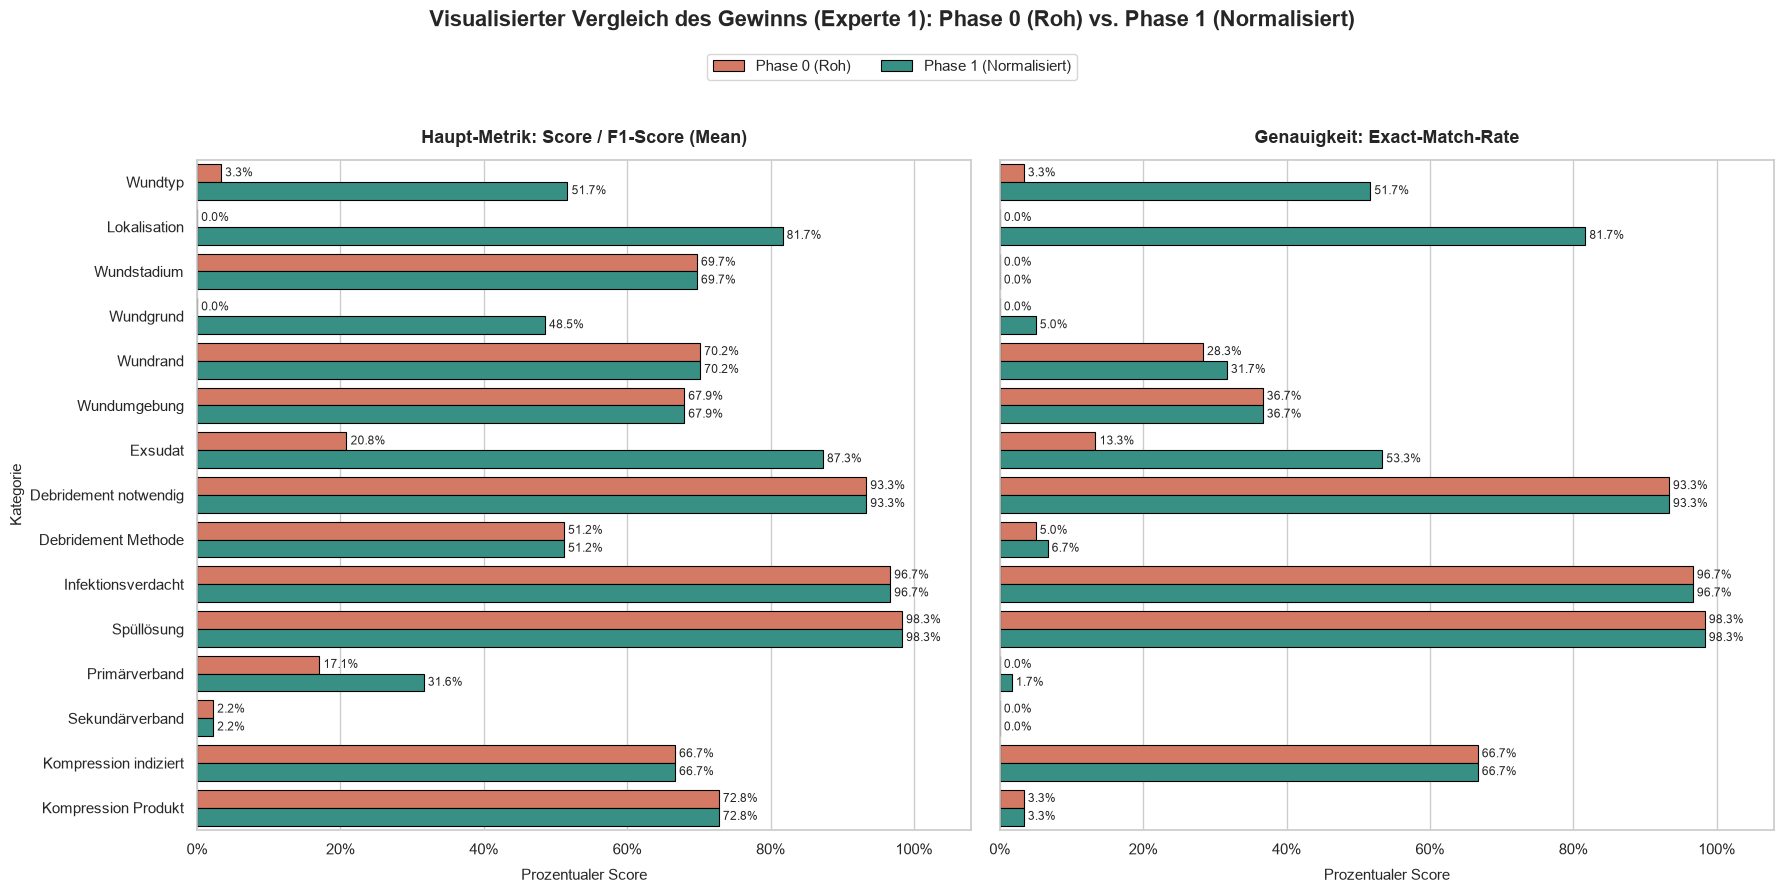

In [11]:
# =====================================================================
# KONSENS-SCORE (LLM VS. BEST-OF-BOTH-EXPERTS: MAXIMUM DER SCORES)
# =====================================================================

# 1. Berechne die Konsens-Zusammenfassungen für beide Phasen (Roh vs. Normalisiert)
df_consensus_raw = calculate_consensus_summary_LR(normalised=False)
df_consensus_norm = calculate_consensus_summary_LR(normalised=True)

# 2. Zeichne das Vergleichsdiagramm
print("Diagramm für den Konsens-Score (Best-of-Both-Experts) wird generiert...")
plot_gt_comparison(df_consensus_raw, df_consensus_norm)

### Sortierter Vergleich: Experte 1


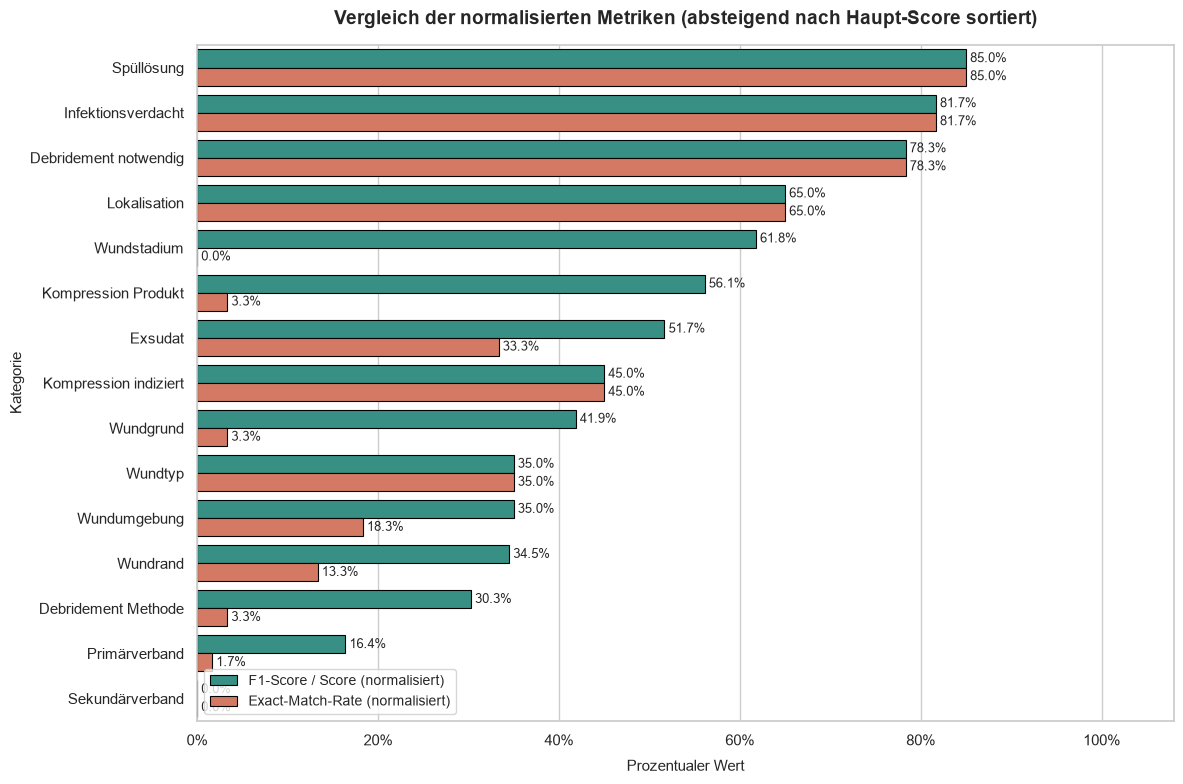

In [12]:
from utils_notebook.plot_compare import plot_sorted_norm_comparison
plot_sorted_norm_comparison(df_summary_norm_exp1)


### Sortierter Vergleich: Konsensus


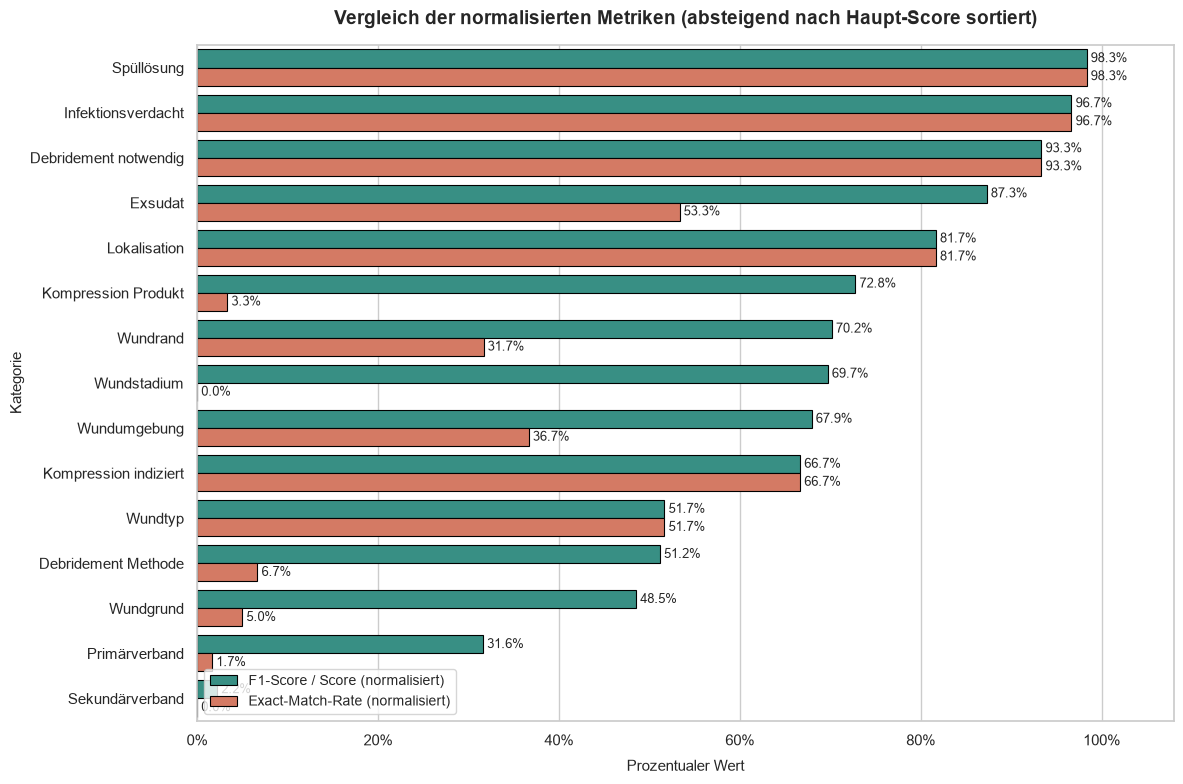

In [13]:
plot_sorted_norm_comparison(df_consensus_norm)


In [14]:
from utils_notebook.LR_utils_notebook.product_sets_comparison import display_product_sets_comparison

# Führt die Berechnung aus und zeigt Zusammenfassung sowie Detailtabelle im L&R Design an:
df_summary, df_detail = display_product_sets_comparison()

Metrik / Vergleich,Score / F1-Score
Experten-Einigkeit untereinander (F1 Mean),33.3%
LLM vs. Experte 1 (F1 Mean),13.7%
LLM vs. Experte 2 (F1 Mean),20.7%
LLM Best Match (Max F1 Mean),23.9%
LLM Durchschnitt (Mean F1),17.2%


image_id,Experte 1 Produktset,Experte 2 Produktset,LLM Output Produktset,Experten-Einigkeit (F1),LLM vs Exp 1 (F1),LLM vs Exp 2 (F1),LLM Best Match (F1),LLM Mean (F1)
wunde_01,"debrisoft pad, suprasorb cnp","chirurgisches debridement, debrisoft lolly, suprasorb cnp, suprasorb x + phmb","autolytisches debridement, chirurgisches (scharfes) debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb a + ag, vliwaktiv ag, vliwasorb pro",33.3%,0.0%,0.0%,0.0%,0.0%
wunde_02,"debrisoft pad, fixierbinden und universalbinden. rollenpflaster, solvaline n, suprasorb p + phmb","chirurgisches debridement, debrisoft duo, solvaline n, suprasorb cnp, suprasorb x + phmb","curafix h, haftelast latexfrei, metalline kompresse, suprasorb p sensitive, suprasorb x, vliwazell",22.2%,0.0%,0.0%,0.0%,0.0%
wunde_03,suprasorb p sensiflex,"lomatuell pro, solvaline n, suprasorb p sensiflex","curafix h, lomatuell pro, silkafix, suprasorb liquacel pro, suprasorb p sensitive",50.0%,0.0%,25.0%,25.0%,12.5%
wunde_04,"debrisoft pad, solvaline n, suprasorb x + phmb, universalbinde und rollenpflaster","chirurgisches debridement, debrisoft lolly, suprasorb a + ag, suprasorb p + phmb, suprasorb p sensiflex","chirurgisches debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb a + ag, suprasorb p + phmb, suprasorb p sensitive",0.0%,0.0%,46.2%,46.2%,23.1%
wunde_05,"debrisoft duo, solvaline n, suprasorb x + phmb","chirurgisches debridement, lomatuell h, suprasorb x + phmb","autolytisches debridement, chirurgisches debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb a + ag, suprasorb liquacel pro, vliwasorb pro, vliwazell pro",33.3%,15.4%,15.4%,15.4%,15.4%
wunde_06,"fixierbinde und rollenpflaster, solvaline n, suprasorb x + phmb","chirurgisches debridement, debrisoft duo, solvaline n, suprasorb p + phmb","chirurgisches debridement, curafix h, debrisoft pad, lomatuell pro, porofix, silkafix, suprasorb p sensiflex, suprasorb p sensitive, suprasorb x pro",28.6%,0.0%,15.4%,15.4%,7.7%
wunde_07,"suprasorb cnp, ultraschall","debrisoft pad, lomatuell pro, suprasorb cnp, vliwazell pro","autolytisches debridement, curafix h, debrisoft duo, debrisoft pad, silkafix, suprasorb a pro, suprasorb liquacel pro, suprasorb p",33.3%,0.0%,16.7%,16.7%,8.3%
wunde_08,suprasorb p sensiflex,—,"autolytisches debridement, curafix h, curapor, curapor transparent, debrisoft pad, silkafix, suprasorb x, suprasorb x pro",0.0%,0.0%,0.0%,0.0%,0.0%
wunde_09,—,"chirurgisches debridement, debrisoft duo","autolytisches debridement, chirurgisches debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb f protect, suprasorb g gel-kompresse, suprasorb h",0.0%,0.0%,36.4%,36.4%,18.2%
wunde_10,"debrisoft duo, suprasorb f protect, suprasorb g gel-kompresse","chirurgisches debridement, debrisoft pad, solvaline n, suprasorb cnp, suprasorb liquacel pro, suprasorb x + phmb, vliwazell pro","autolytisches debridement, chirurgisches debridement, curafix h, debrisoft duo, porofix, suprasorb a pro, suprasorb liquacel pro, suprasorb p sensitive, vliwasorb pro",0.0%,16.7%,25.0%,25.0%,20.8%


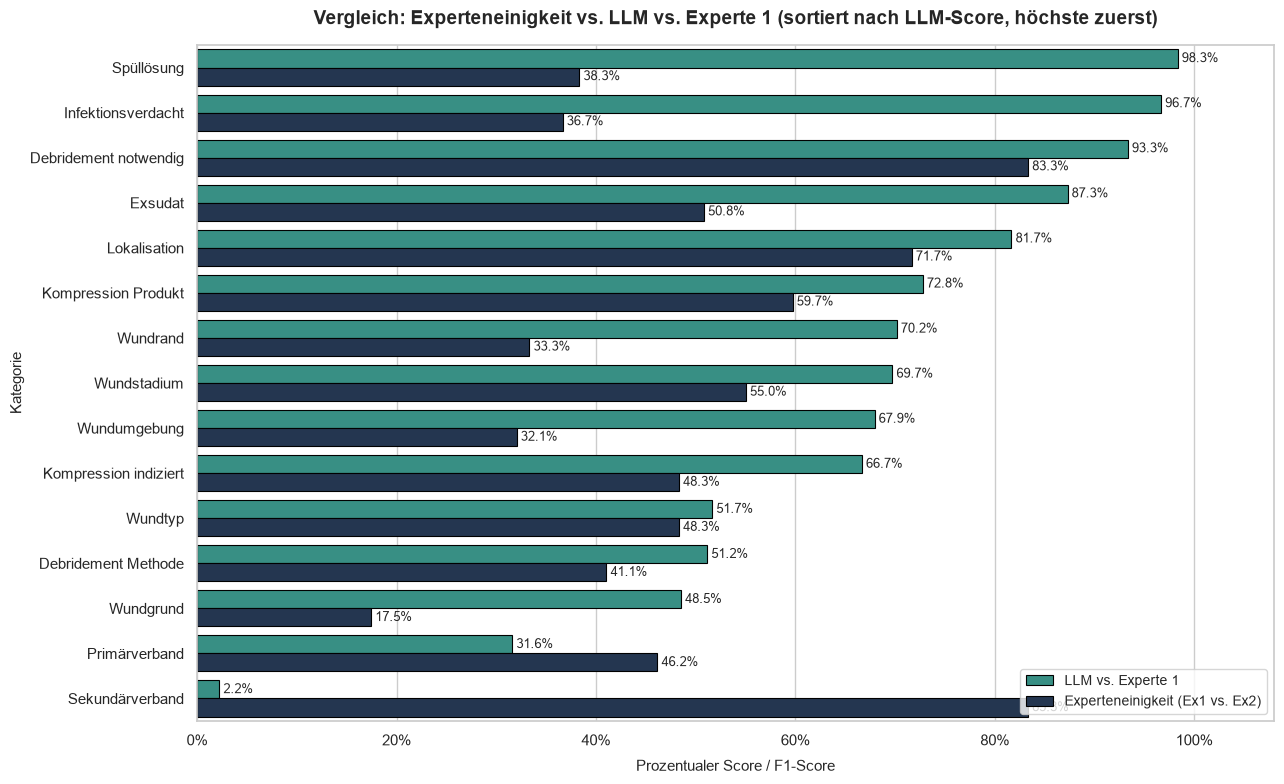

In [15]:
from utils_notebook.LR_utils_notebook.compare_LR import (
    calculate_experts_summary_LR,
    calculate_consensus_summary_LR
)
from utils_notebook.plot_compare import plot_combined_single_chart

# 1. Daten berechnen (normalisiert)
df_experts_norm = calculate_experts_summary_LR(normalised=True)
df_consensus_norm = calculate_consensus_summary_LR(normalised=True)

# 2. Einzelner Plot: Experteneinigkeit vs. kombinierten LLM-Experten-Score (sortiert nach LLM-Score, höchste zuerst)
plot_combined_single_chart(df_experts_norm, df_consensus_norm)

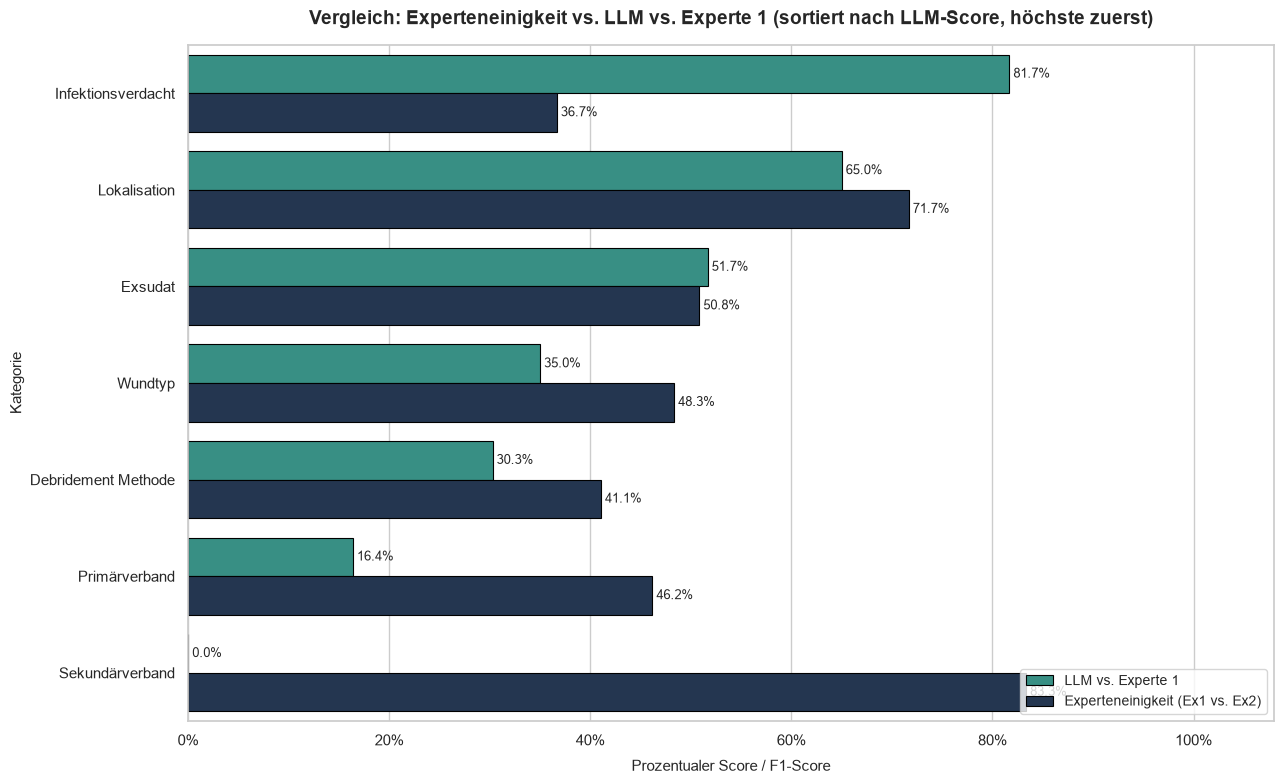

In [16]:
from utils_notebook.LR_utils_notebook.compare_LR import calculate_experts_summary_LR, calculate_summary_LR
from utils_notebook.plot_compare import plot_combined_single_chart

df_experts_norm = calculate_experts_summary_LR(normalised=True)
df_exp1_norm = calculate_summary_LR(expert_id=1, normalised=True)
df_exp2_norm = calculate_summary_LR(expert_id=2, normalised=True)

selected_categories = [
    'Wundtyp', 'Exsudat', 'Lokalisation', 'Debridement Methode', 'Primärverband', 'Sekundärverband', 'Infektionsverdacht'
]
df_experts_filtered = df_experts_norm[df_experts_norm['Kategorie'].isin(selected_categories)]
df_exp1_filtered = df_exp1_norm[df_exp1_norm['Kategorie'].isin(selected_categories)]
df_exp2_filtered = df_exp2_norm[df_exp2_norm['Kategorie'].isin(selected_categories)]

plot_combined_single_chart(df_experts_filtered, df_exp1_filtered, expert_label='Experte 1')


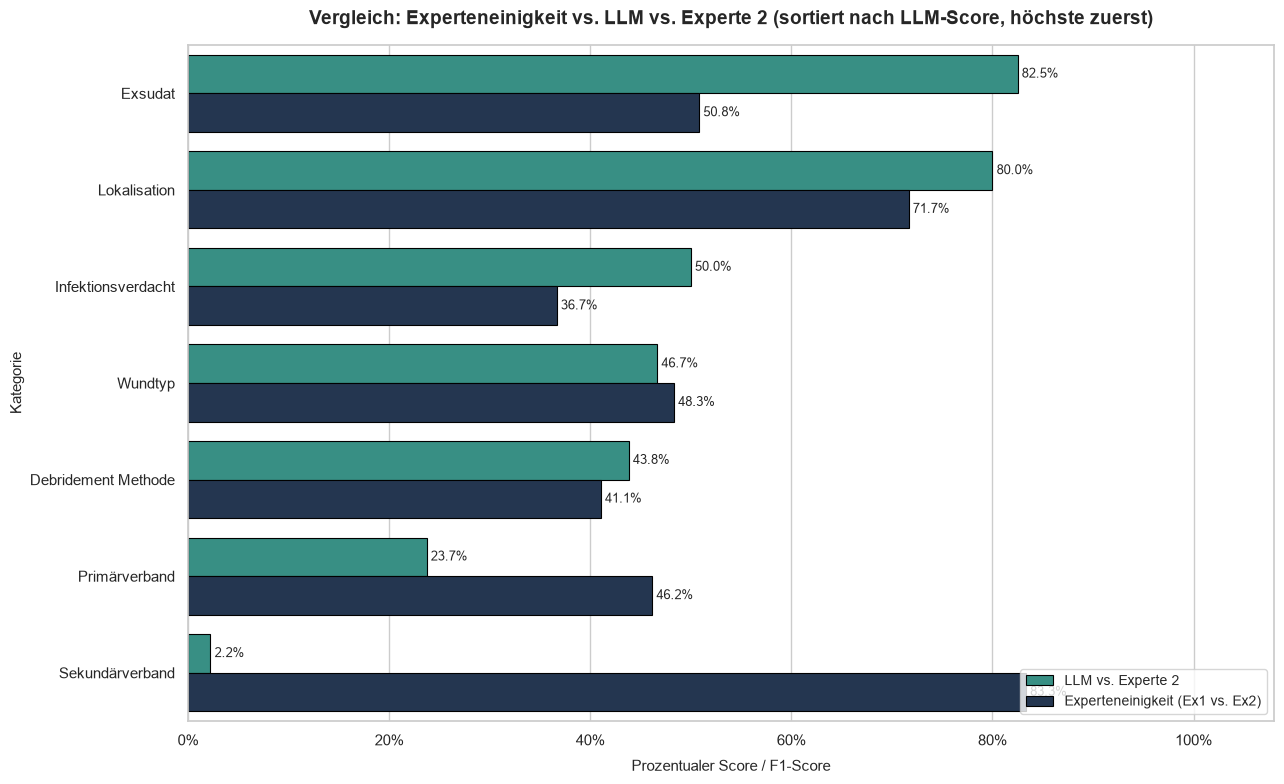

In [17]:
plot_combined_single_chart(df_experts_filtered, df_exp2_filtered, expert_label='Experte 2')


In [18]:
from utils_notebook.LR_utils_notebook.compare_LR import evaluate_baselines_dual

# Pfade zu den normalisierten Ground-Truths und LLM-Outputs
gt1_path = "data/ground_truth/lohmann_rauscher/Experte1_LR_GroundTruth_normalised.csv"
gt2_path = "data/ground_truth/lohmann_rauscher/Experte2_LR_GroundTruth_normalised.csv"
llm_path = "data/llm_outputs/zero_shot_lr/zero_shot_lr_normalised.csv"

# Duale Baseline-Auswertung (Random + LOO Majority vs. Experte 1 & Experte 2)
results = evaluate_baselines_dual(
    gt1_path_or_dict=gt1_path,
    gt2_path_or_dict=gt2_path,
    llm_path_or_dict=llm_path,
    n_runs=1000,
    seed=42
)

# 1. Aggregierte Ergebnistabelle anzeigen (Random / Majority / LLM / Inter-Rater / Abdeckung)
print("=" * 80)
print("ERGEBNISTABELLE (DUALE BASELINE- & EXPERTEN-EVALUIERUNG)")
print("=" * 80)
display(results["summary_table"])

# 2. Optional: Per-Bild-Tabelle für spätere Bootstrap-Konfidenzintervalle aufrufen
df_per_image = results["per_image_table"]

[Experte 1] GT-Produkt 'Ultraschall' in Bild wunde_07 (Feld 'debridement') IST NICHT IM TEILKATALOG.
[Experte 1] GT-Produkt 'amorphes Gel' in Bild wunde_12 (Feld 'primaerverband') IST NICHT IM TEILKATALOG.
[Experte 1] GT-Produkt 'Fixierbinde' in Bild wunde_14 (Feld 'primaerverband') IST NICHT IM TEILKATALOG.
[Experte 1] GT-Produkt 'amorphes Gel' in Bild wunde_15 (Feld 'primaerverband') IST NICHT IM TEILKATALOG.
[Experte 1] GT-Produkt 'amorphes Gel' in Bild wunde_19 (Feld 'primaerverband') IST NICHT IM TEILKATALOG.
[Experte 1] GT-Produkt 'amorphes Gel' in Bild wunde_24 (Feld 'primaerverband') IST NICHT IM TEILKATALOG.
[Experte 1] GT-Produkt 'amorphes Gel' in Bild wunde_28 (Feld 'primaerverband') IST NICHT IM TEILKATALOG.
[Experte 1] GT-Produkt 'amorphes Gel' in Bild wunde_36 (Feld 'primaerverband') IST NICHT IM TEILKATALOG.
[Experte 1] GT-Produkt 'amorphes Gel' in Bild wunde_42 (Feld 'primaerverband') IST NICHT IM TEILKATALOG.
[Experte 1] GT-Produkt 'amorphes Gel' in Bild wunde_45 (Feld

ERGEBNISTABELLE (DUALE BASELINE- & EXPERTEN-EVALUIERUNG)


,Feld,Metrik,GT1 Random (Mean [95% CI]),GT1 Majority,GT1 LLM,GT2 Random (Mean [95% CI]),GT2 Majority,GT2 LLM,Experte 1 vs Experte 2 (Inter-Rater),GT1 n_empty,GT1 non_catalog_rate,GT2 n_empty,GT2 non_catalog_rate
0,lokalisation,Accuracy,"0.099 [0.033, 0.183]",0.400000,0.650000,"0.121 [0.050, 0.200]",0.433333,0.800000,0.716667,2,0.0%,0,0.0%
1,exsudatmenge,QWK,"-0.005 [-0.268, 0.258]",0.000000,0.522727,"0.007 [-0.217, 0.222]",0.000000,0.493100,0.350515,25,0.0%,3,0.0%
2,exsudatmenge_dist,Distance Score,"0.389 [0.346, 0.433]",0.508333,0.516667,"0.638 [0.583, 0.692]",0.833333,0.854167,0.495833,25,0.0%,3,0.0%
3,debridement,Macro-F1,"0.344 [0.275, 0.425]",0.483333,0.302778,"0.340 [0.272, 0.417]",0.650000,0.438333,0.410556,12,1.9%,3,0.9%
4,primaerverband,Macro-F1,"0.124 [0.083, 0.175]",0.440000,0.163889,"0.201 [0.142, 0.267]",0.765000,0.237222,0.461667,3,9.8%,2,2.3%
5,sekundaerverband,Macro-F1,"0.883 [0.883, 0.883]",0.883333,0.000000,"0.938 [0.933, 0.967]",0.983333,0.022222,0.833333,53,100.0%,56,0.0%
6,kompression,Macro-F1,"0.619 [0.600, 0.647]",0.805556,0.561111,"0.881 [0.869, 0.897]",0.977619,0.687037,0.597262,36,0.0%,52,0.0%
